# Q1 results figures -- selected, final set

Consolidates `results_figures_q1_final.ipynb` (built by a concurrent session, 2026-08-21) into the
actual set to use in the dissertation, with two corrections found while reviewing that notebook:

1. **Figure 2** only ringed 3 of the 6 variables now known to disagree between EN/LMM
   (topex/tas_mean/soilgrids_ph) -- extended to all 6, adding ceh_twi, gwa_weibull_a_50m,
   local_relief_500m as rows with the same real-signal/artifact ring encoding.
2. **Figure 4** selected its "above/below curve" example plots via `.sort_values(...).head(2)` --
   the single most extreme plots in the ~71,000-row population (+31.3m/-26.3m residual), not
   representative examples. Replaced with plots nearest the 90th/10th percentile (+6.4m/-7.9m).

Also simplifies Figure 3 to one residual map instead of two near-identical EN/XGBoost maps side
by side (both showed the same visual pattern despite a real 2x Moran's I difference -- the
Moran's I line panel already carries that comparison clearly; a second map added space without a
clear payoff). Figure 1 and the VIF appendix are ported unchanged -- no issues found in either.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks: walk upward
# until a folder containing both README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from models.common.geo import load_compartment_boundaries, load_plot_coordinates
from models.growth_curve_attribution.residual_spatial_autocorrelation_check import compute_residual_morans_i
from notebooks.results_figures_style import (
    COLOR_EN, COLOR_XGBOOST, COLOR_NEUTRAL_EDGE, DIVERGING_CMAP, apply_rcparams,
)

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 5
COHORT = "4survey"  # Q1 has no 6survey arm -- too few compartments for spatial analysis
SET4_RUN_DIR = project_root / "outputs" / "spatial_block_kfold" / "rq2_attribution_nested_set4_gated_all_vif" / COHORT
SET_RUN_NAMES = {
    "Set1": "rq2_attribution_nested_set1_baseline",
    "Set2": "rq2_attribution_nested_set2_top10",
    "Set3": "rq2_attribution_nested_set3_gated_terrain_wind_vif",
    "Set4": "rq2_attribution_nested_set4_gated_all_vif",
}
# Extended from the 8-variable curated list (q1_final.ipynb) to 11 -- adds the 3 variables this
# session's full 19-variable check found also disagree between EN/LMM (ceh_twi,
# gwa_weibull_a_50m, local_relief_500m), so Figure 2 shows all 6 disagreeing variables, not 3.
CURATED_VARIABLES = [
    "CanopyCover", "time_since_thinning", "time_since_thinning_missing",
    "slope_degrees", "topex", "tas_mean", "soilgrids_ph", "chelsa_bio12_precip_mm",
    "ceh_twi", "gwa_weibull_a_50m", "local_relief_500m",
]

def pooled_r2(observed, predicted):
    residuals = observed - predicted
    ss_res = (residuals ** 2).sum()
    ss_tot = ((observed - observed.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

## Figure 1 -- CanopyCover ablation (Headline 1: stand structure dominates, not circular)

**Ported, unchanged**, from `results_figures_q1_final.ipynb` -- no issues found on review. `R2`
with vs. without CanopyCover (EN and XGBoost), and mean |SHAP| with vs. without CanopyCover --
`dist_to_road`'s bar does NOT grow to compensate, the actual evidence behind "CanopyCover carries
real, non-redundant signal."

In [3]:
# --- WITH CanopyCover: pooled R2 (from saved predictions.csv) + mean|SHAP| (from saved
# xgboost_shap_values.csv), Set4, 4survey. ---
with_frames, with_shap_frames = [], []
for fold in range(N_FOLDS):
    with_frames.append(pd.read_csv(SET4_RUN_DIR / f"fold_{fold}" / "predictions.csv"))
    with_shap_frames.append(pd.read_csv(SET4_RUN_DIR / f"fold_{fold}" / "xgboost_shap_values.csv"))
with_pooled = pd.concat(with_frames, ignore_index=True)
with_pooled = with_pooled[with_pooled["split"] == "test"] if "split" in with_pooled.columns else with_pooled
with_shap_pooled = pd.concat(with_shap_frames, ignore_index=True)

en_r2_with = pooled_r2(with_pooled["observed"], with_pooled["elastic_net_predicted"])
xgb_r2_with = pooled_r2(with_pooled["observed"], with_pooled["xgboost_predicted"])
shap_feature_cols_with = [c for c in with_shap_pooled.columns if c not in ("identification", "fold")]
mean_abs_shap_with = with_shap_pooled[shap_feature_cols_with].abs().mean().sort_values(ascending=False)

print(f"WITH CanopyCover -- pooled R2: EN={en_r2_with:.3f}, XGBoost={xgb_r2_with:.3f}")

# --- WITHOUT CanopyCover: from the live re-run's saved JSON ---
WITHOUT_CANOPY_RESULTS = (
    project_root / "outputs" / "spatial_block_kfold" / "rq2_attribution_nested_set4_no_canopycover"
    / "4survey" / "ablation_results.json"
)
without_results = json.load(open(WITHOUT_CANOPY_RESULTS))
en_r2_without_per_fold = np.array(without_results["en_r2_without_canopy_per_fold"])
xgb_r2_without_per_fold = np.array(without_results["xgb_r2_without_canopy_per_fold"])
mean_abs_shap_without = pd.Series(without_results["mean_abs_shap_without_canopy"]).sort_values(ascending=False)

en_r2_without = en_r2_without_per_fold.mean()
xgb_r2_without = xgb_r2_without_per_fold.mean()
print(f"WITHOUT CanopyCover -- fold-mean R2: EN={en_r2_without:.3f}+/-{en_r2_without_per_fold.std():.3f}, "
      f"XGBoost={xgb_r2_without:.3f}+/-{xgb_r2_without_per_fold.std():.3f}")

WITH CanopyCover -- pooled R2: EN=0.358, XGBoost=0.395
WITHOUT CanopyCover -- fold-mean R2: EN=0.231+/-0.062, XGBoost=0.249+/-0.076


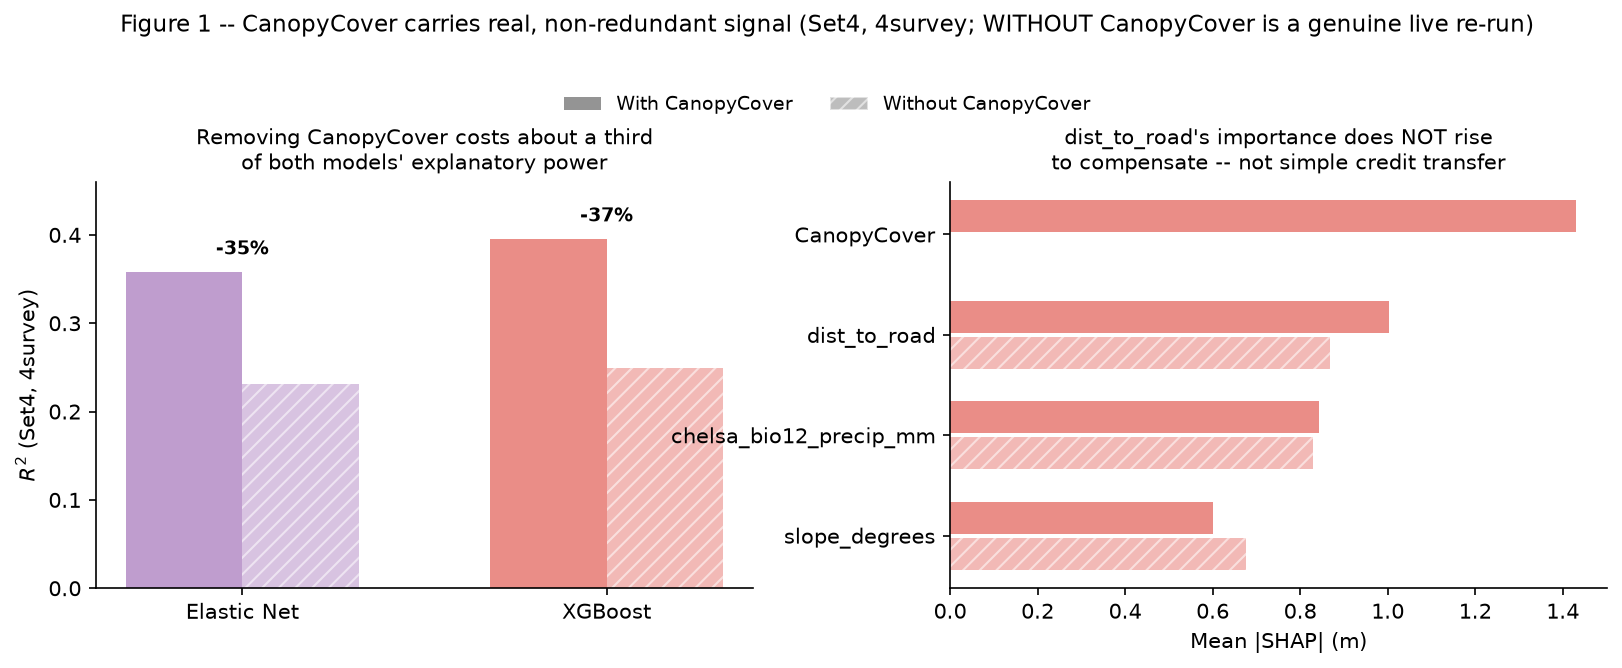

In [4]:
fig, (ax_r2, ax_shap) = plt.subplots(1, 2, figsize=(13, 4.3))

methods = ["Elastic Net", "XGBoost"]
r2_with = [en_r2_with, xgb_r2_with]
r2_without = [en_r2_without, xgb_r2_without]
bar_x = np.arange(len(methods))
bar_width = 0.32

# "Without" bars now use a hatch pattern (not just lower alpha) -- the with/without encoding is
# then hue-independent (readable the same way on both the purple EN bars and the red XGBoost
# bars), fixing the earlier mismatch where the legend used plain grey swatches that didn't visibly
# correspond to either bar colour.
ax_r2.bar(bar_x - bar_width / 2, r2_with, bar_width, color=[COLOR_EN, COLOR_XGBOOST], alpha=0.9)
ax_r2.bar(bar_x + bar_width / 2, r2_without, bar_width, color=[COLOR_EN, COLOR_XGBOOST], alpha=0.55,
          hatch="///", edgecolor="white", linewidth=0)
for x, with_val, without_val in zip(bar_x, r2_with, r2_without):
    drop_pct = (with_val - without_val) / with_val * 100
    ax_r2.annotate(f"-{drop_pct:.0f}%", xy=(x, max(with_val, without_val) + 0.02),
                    ha="center", fontsize=9, fontweight="bold")
ax_r2.set_xticks(bar_x)
ax_r2.set_xticklabels(methods)
ax_r2.set_ylabel("$R^2$ (Set4, 4survey)")
ax_r2.set_ylim(0, 0.46)
ax_r2.set_title("Removing CanopyCover costs about a third\nof both models' explanatory power", fontsize=10)

compare_vars = ["CanopyCover", "dist_to_road", "chelsa_bio12_precip_mm", "slope_degrees"]
with_vals = [mean_abs_shap_with.get(v, np.nan) for v in compare_vars]
without_vals = [mean_abs_shap_without.get(v, np.nan) for v in compare_vars]

y_positions = np.arange(len(compare_vars))
ax_shap.barh(y_positions - 0.18, with_vals, height=0.32, color=COLOR_XGBOOST, alpha=0.9)
ax_shap.barh(y_positions + 0.18, without_vals, height=0.32, color=COLOR_XGBOOST, alpha=0.55,
             hatch="///", edgecolor="white", linewidth=0)
ax_shap.set_yticks(y_positions)
ax_shap.set_yticklabels(compare_vars)
ax_shap.invert_yaxis()
ax_shap.set_xlabel("Mean |SHAP| (m)")
ax_shap.set_title("dist_to_road's importance does NOT rise\nto compensate -- not simple credit transfer", fontsize=10)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#888888", alpha=0.9, label="With CanopyCover"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#888888", alpha=0.55, hatch="///", edgecolor="white", label="Without CanopyCover"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.90), ncol=2,
           fontsize=9, frameon=False)

fig.suptitle("Figure 1 -- CanopyCover carries real, non-redundant signal "
             "(Set4, 4survey; WITHOUT CanopyCover is a genuine live re-run)",
             fontsize=11, y=1.0)
fig.subplots_adjust(top=0.74, wspace=0.3)
fig.savefig(FIGURES_DIR / "q1_selected_fig1_canopycover_ablation.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 2 -- attribution: three lenses + mechanism (Headline 2)

**Fixed**: extended from 8 to 11 curated variables and from 4 to 7 mechanism-tested variables, so
all 6 variables this session's full 19-variable check found genuinely unstable are ringed
(green=real local signal survives within-compartment mean-centring, red=collapses to a
between-compartment artifact) -- not just the 3 originally checked (topex/tas_mean/soilgrids_ph).

In [5]:
# --- Panel A + SHAP data: EN + LMM coefficients (Set3, Set4) + XGBoost SHAP (Set4 only) ---
def load_set_coefficients(set_label):
    set_dir = project_root / "outputs" / "spatial_block_kfold" / SET_RUN_NAMES[set_label] / COHORT
    en_frames, nlme_frames = [], []
    for fold in range(N_FOLDS):
        fold_dir = set_dir / f"fold_{fold}"
        en_coef = pd.read_csv(fold_dir / "elastic_net_coefficients.csv", index_col=0)
        en_coef.columns = ["coefficient"]
        en_coef["fold"] = fold
        en_frames.append(en_coef.reset_index(names="variable"))

        with open(fold_dir / "nlme_fixed_effects.json") as f:
            nlme_json = json.load(f)["fixed_effects"]
        nlme_frames.append(pd.DataFrame(
            [{"variable": var, "coefficient": vals["coefficient"], "fold": fold} for var, vals in nlme_json.items()]
        ))
    en_all = pd.concat(en_frames, ignore_index=True)
    nlme_all = pd.concat(nlme_frames, ignore_index=True)
    en_summary = en_all.groupby("variable")["coefficient"].agg(["mean", "std"]).rename(
        columns={"mean": "en_mean", "std": "en_sd"})
    nlme_summary = nlme_all.groupby("variable")["coefficient"].agg(["mean", "std"]).rename(
        columns={"mean": "nlme_mean", "std": "nlme_sd"})
    # NOT .fillna(0) -- Set3 is terrain/wind only, genuinely has no climate/soil columns.
    combined = en_summary.join(nlme_summary, how="outer")
    return combined.reindex(CURATED_VARIABLES)

fig2_set3 = load_set_coefficients("Set3")
fig2_set4 = load_set_coefficients("Set4")

mean_abs_shap_fig2 = with_shap_pooled[shap_feature_cols_with].abs().mean()
shap_curated = mean_abs_shap_fig2.reindex(CURATED_VARIABLES)
print("Set4 mean |SHAP|, curated variables:\n", shap_curated)

Set4 mean |SHAP|, curated variables:
 CanopyCover                    1.429899
time_since_thinning            0.104481
time_since_thinning_missing    0.042669
slope_degrees                  0.601267
topex                          0.324959
tas_mean                       0.245941
soilgrids_ph                   0.144467
chelsa_bio12_precip_mm         0.842836
ceh_twi                        0.090111
gwa_weibull_a_50m              0.167567
local_relief_500m              0.187672
dtype: float64


In [6]:
# --- Mechanism markers: within-compartment mean-centred correlation vs. raw pooled
# correlation. Extended from 4 to 7 variables -- adds ceh_twi, gwa_weibull_a_50m,
# local_relief_500m (the 3 new unstable variables found via the full 19-variable check) alongside
# the original 4 (topex/tas_mean/soilgrids_ph/chelsa_bio12_precip_mm). Same method already
# verified this session (TEMP_rq2b_topex_tasmean_nonlinearity_check_2026-08-20.tex).
env_features = pd.read_parquet(project_root / "data" / "processed" / "environmental" / "plot_environmental_features.parquet")

# NOT including chelsa_bio12_precip_mm here -- it is one of the 2 STABLE variables (EN/LMM
# already agree), not one of the 6 disputed ones this ring is meant to explain. Live-testing it
# with the same threshold found its within/raw retention ratio (33%) is barely different from the
# confirmed-artifact tas_mean (32%) -- applying the disputed-variable test to an undisputed
# variable produced a red "artifact" ring that contradicted the text calling it stable. Left
# unringed rather than silently forced green.
MECHANISM_VARS = {
    "topex": "topex",
    "tas_mean": "tas_mean_4survey",
    "soilgrids_ph": "soilgrids_ph",
    "ceh_twi": "ceh_twi",
    "gwa_weibull_a_50m": "gwa_weibull_a_50m",
    "local_relief_500m": "local_relief_500m",
}
TARGET_COL = "mean_cr_residual_4survey"

mechanism_rows = []
for display_name, column_name in MECHANISM_VARS.items():
    sub = env_features.dropna(subset=[column_name, TARGET_COL, "cpmt"]).copy()
    raw_corr = sub[column_name].corr(sub[TARGET_COL])

    sub["var_centred"] = sub.groupby("cpmt")[column_name].transform(lambda s: s - s.mean())
    sub["target_centred"] = sub.groupby("cpmt")[TARGET_COL].transform(lambda s: s - s.mean())
    within_corr = sub["var_centred"].corr(sub["target_centred"])

    signal_survives = abs(within_corr) >= abs(raw_corr) * 0.5
    mechanism_rows.append({
        "variable": display_name, "raw_corr": raw_corr, "within_corr": within_corr,
        "signal_survives": signal_survives,
    })

mechanism_df = pd.DataFrame(mechanism_rows).set_index("variable")
print(mechanism_df)

                   raw_corr  within_corr  signal_survives
variable                                                 
topex              0.080346     0.214176             True
tas_mean           0.279427     0.089840            False
soilgrids_ph       0.223931     0.035402            False
ceh_twi           -0.105692    -0.010045            False
gwa_weibull_a_50m -0.329607    -0.139664            False
local_relief_500m -0.116573    -0.005466            False


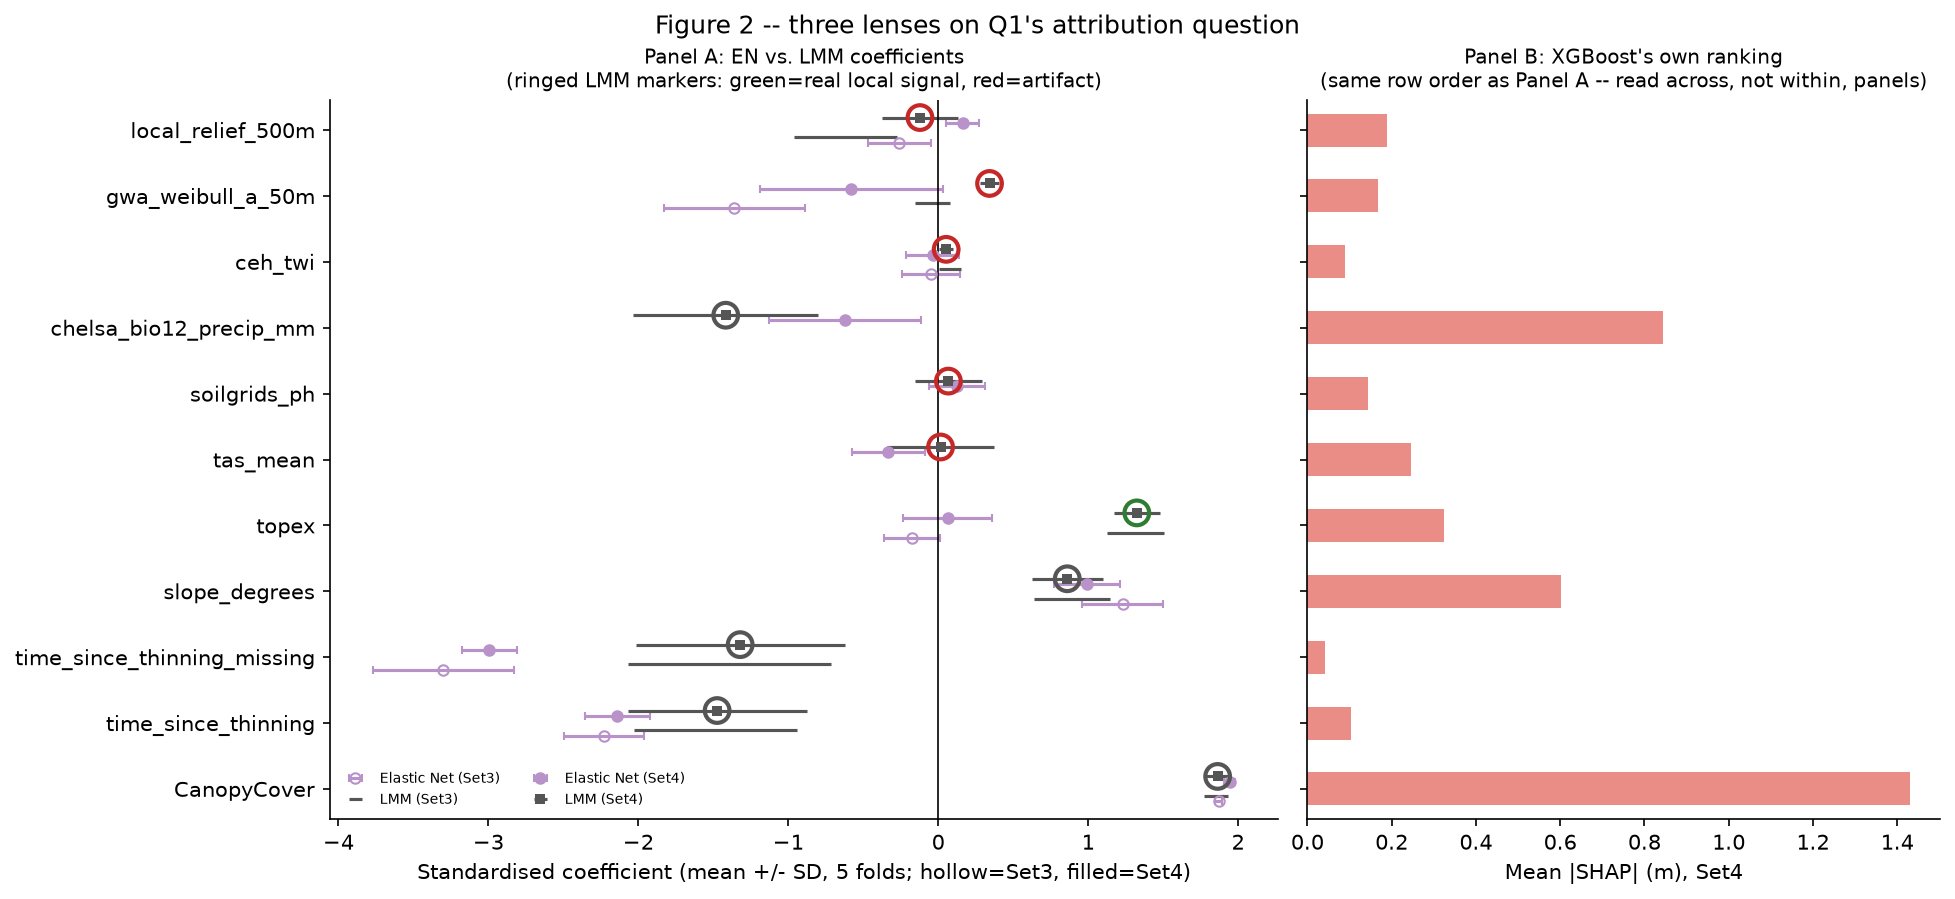

In [7]:
fig, (ax_a, ax_shap) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1.5, 1]}, sharey=True)

y_positions = np.arange(len(CURATED_VARIABLES))
row_offsets = {"Set3": -0.15, "Set4": 0.15}
fill_style = {"Set3": "none", "Set4": "full"}

marker_edge_colors = []
for variable in CURATED_VARIABLES:
    if variable in mechanism_df.index:
        marker_edge_colors.append("#2E7D32" if mechanism_df.loc[variable, "signal_survives"] else "#C62828")
    else:
        marker_edge_colors.append(COLOR_NEUTRAL_EDGE)

for set_label, panel_a_data in [("Set3", fig2_set3), ("Set4", fig2_set4)]:
    offset = row_offsets[set_label]
    ax_a.errorbar(panel_a_data["en_mean"], y_positions + offset - 0.04, xerr=panel_a_data["en_sd"],
                  fmt="o", color=COLOR_EN, markersize=5, capsize=2, fillstyle=fill_style[set_label],
                  label=f"Elastic Net ({set_label})", zorder=2)
    ax_a.errorbar(panel_a_data["nlme_mean"], y_positions + offset + 0.04, xerr=panel_a_data["nlme_sd"],
                  fmt="s", color=COLOR_NEUTRAL_EDGE, markersize=5, capsize=2, fillstyle=fill_style[set_label],
                  label=f"LMM ({set_label})", zorder=2,
                  markeredgecolor=None, markeredgewidth=0)
    if set_label == "Set4":
        for y, edge_color, variable in zip(y_positions, marker_edge_colors, CURATED_VARIABLES):
            if pd.notna(panel_a_data.loc[variable, "nlme_mean"]):
                ax_a.scatter([panel_a_data.loc[variable, "nlme_mean"]], [y + offset + 0.04],
                             s=140, facecolors="none", edgecolors=edge_color, linewidths=2, zorder=3)

ax_a.axvline(0, color="black", linewidth=0.8)
ax_a.set_yticks(y_positions)
ax_a.set_yticklabels(CURATED_VARIABLES, fontsize=10)
ax_a.set_xlabel("Standardised coefficient (mean +/- SD, 5 folds; hollow=Set3, filled=Set4)")
ax_a.set_title("Panel A: EN vs. LMM coefficients\n(ringed LMM markers: green=real local signal, red=artifact)", fontsize=9.5)
ax_a.legend(fontsize=6.5, frameon=False, loc="lower left", ncol=2)

ax_shap.barh(y_positions, shap_curated.values, height=0.5, color=COLOR_XGBOOST, alpha=0.9)
ax_shap.set_xlabel("Mean |SHAP| (m), Set4")
ax_shap.set_title("Panel B: XGBoost's own ranking\n(same row order as Panel A -- read across, not within, panels)", fontsize=9.5)

fig.suptitle("Figure 2 -- three lenses on Q1's attribution question", fontsize=12)
ax_a.margins(y=0.02)
plt.tight_layout(pad=0.6)
fig.savefig(FIGURES_DIR / "q1_selected_fig2_attribution_three_lenses.png", dpi=200)
plt.show()

## Figure 3 -- spatial clustering, XGBoost removes more (Headline 3, motivates Q2)

**Simplified from the 2-map version**: `results_figures_q1_final.ipynb` put EN and XGBoost's
Set4 residual maps side by side on a shared colour scale. Reviewed both -- they show the same
visual pattern (same compartments red/blue) despite the real ~2x Moran's I difference; the
statistical difference is real but not visually obvious at this scale, so a second map added
panel space without a clear payoff. Kept one map (EN, matching the original `results_q1_rq2b`
figure) -- the Moran's I line panel below already carries the quantitative EN-vs-XGBoost
comparison clearly.

In [8]:
# --- Panel B + C data: pooled predictions per set, residual, Moran's I, and Set4's own map ---
coordinates = load_plot_coordinates()

panel_b_rows = []
set4_pooled_with_xy = None
for set_label, run_name in SET_RUN_NAMES.items():
    frames = []
    for fold in range(N_FOLDS):
        p = project_root / "outputs" / "spatial_block_kfold" / run_name / COHORT / f"fold_{fold}" / "predictions.csv"
        frames.append(pd.read_csv(p))
    pooled = pd.concat(frames, ignore_index=True)
    pooled = pooled[pooled["split"] == "test"] if "split" in pooled.columns else pooled
    pooled = pooled.merge(coordinates, on="identification", how="left")
    pooled["en_residual"] = pooled["observed"] - pooled["elastic_net_predicted"]
    pooled["xgb_residual"] = pooled["observed"] - pooled["xgboost_predicted"]

    en_i, en_p, en_n, en_range_m, en_status = compute_residual_morans_i(pooled["x"], pooled["y"], pooled["en_residual"])
    xgb_i, xgb_p, xgb_n, xgb_range_m, xgb_status = compute_residual_morans_i(pooled["x"], pooled["y"], pooled["xgb_residual"])
    panel_b_rows.append({"set": set_label, "method": "Elastic Net", "morans_i": en_i, "p_value": en_p, "range_m": en_range_m})
    panel_b_rows.append({"set": set_label, "method": "XGBoost", "morans_i": xgb_i, "p_value": xgb_p, "range_m": xgb_range_m})
    print(f"{set_label}: EN Moran's I={en_i:.3f} (p={en_p:.3f}), XGB Moran's I={xgb_i:.3f} (p={xgb_p:.3f})")

    if set_label == "Set4":
        set4_pooled_with_xy = pooled

panel_b_data = pd.DataFrame(panel_b_rows)

  semivariogram range = 1665m (status: resolved)


  semivariogram range = 1675m (status: resolved)


Set1: EN Moran's I=0.145 (p=0.001), XGB Moran's I=0.146 (p=0.001)


  semivariogram range = 1488m (status: resolved)


  semivariogram range = 1385m (status: resolved)


...

  semivariogram range = 1459m (status: resolved)


Set3: EN Moran's I=0.110 (p=0.001), XGB Moran's I=0.077 (p=0.001)


  semivariogram range = 1739m (status: resolved)


  semivariogram range = 1671m (status: resolved)


Set4: EN Moran's I=0.103 (p=0.001), XGB Moran's I=0.054 (p=0.001)


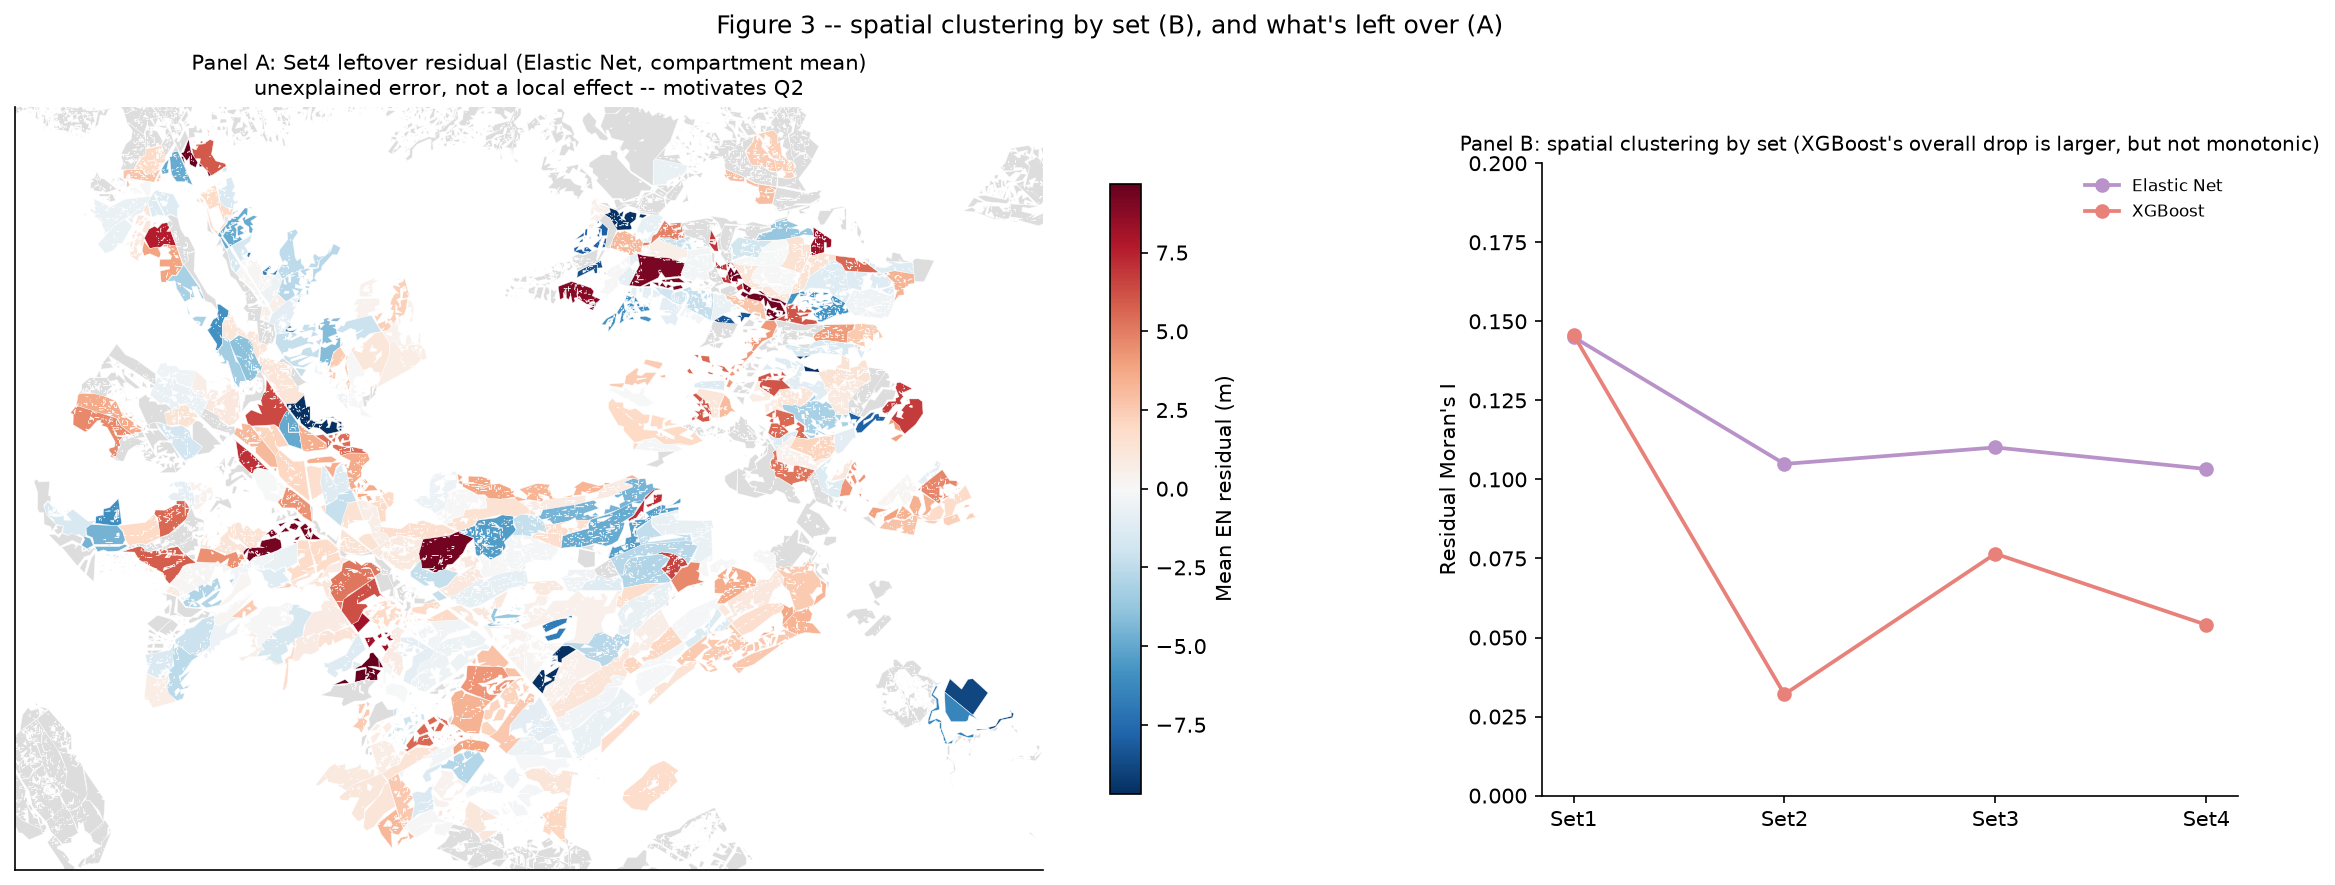

In [9]:
fig = plt.figure(figsize=(16, 6.2))
# Manual axes positioning, not gridspec -- the map's fixed aspect ratio (equal, ~1.58:1 for this
# compartment layout) otherwise shrinks inside a gridspec cell, leaving empty gutters. Sized
# explicitly to the map's own aspect instead. Side-by-side layout (map left, larger; Moran's I
# line right, narrower) -- map height drives its width (height x 1.58).
ax_c = fig.add_axes([0.02, 0.06, 0.565, 0.82])
ax_b = fig.add_axes([0.68, 0.14, 0.29, 0.68])

# --- Panel A (top): Set4 EN residual, compartment mean, mapped ---
en_compartment_mean = set4_pooled_with_xy.groupby("cpmt")["en_residual"].mean().reset_index()
boundaries = load_compartment_boundaries()
en_mapped = boundaries.merge(en_compartment_mean, on="cpmt", how="left")
vmax = en_mapped["en_residual"].abs().quantile(0.98)
norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

data_bounds = boundaries[boundaries["cpmt"].isin(en_compartment_mean["cpmt"])].total_bounds
x_margin = (data_bounds[2] - data_bounds[0]) * 0.03
y_margin = (data_bounds[3] - data_bounds[1]) * 0.03

en_mapped.plot(column="en_residual", cmap=DIVERGING_CMAP, norm=norm, ax=ax_c,
               edgecolor="white", linewidth=0.2, missing_kwds={"color": "#DDDDDD"})
ax_c.set_title("Panel A: Set4 leftover residual (Elastic Net, compartment mean)\nunexplained error, not a local effect -- motivates Q2", fontsize=10)
ax_c.set_aspect("equal")
ax_c.set_xticks([]); ax_c.set_yticks([])
ax_c.set_xlim(data_bounds[0] - x_margin, data_bounds[2] + x_margin)
ax_c.set_ylim(data_bounds[1] - y_margin, data_bounds[3] + y_margin)
sm = plt.cm.ScalarMappable(cmap=DIVERGING_CMAP, norm=norm)
fig.colorbar(sm, ax=ax_c, shrink=0.8, label="Mean EN residual (m)")

# --- Panel B (bottom): Moran's I by set ---
for method, color in [("Elastic Net", COLOR_EN), ("XGBoost", COLOR_XGBOOST)]:
    subset = panel_b_data[panel_b_data["method"] == method]
    ax_b.plot(subset["set"], subset["morans_i"], marker="o", color=color, label=method, linewidth=1.8)
ax_b.set_ylim(0, 0.2)
ax_b.set_ylabel("Residual Moran's I")
ax_b.set_title("Panel B: spatial clustering by set (XGBoost's overall drop is larger, but not monotonic)", fontsize=9.5)
ax_b.legend(fontsize=8, frameon=False)

fig.suptitle("Figure 3 -- spatial clustering by set (B), and what's left over (A)", fontsize=12)
fig.savefig(FIGURES_DIR / "q1_selected_fig3_spatial_clustering.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure 4 -- example trajectories by residual tier (scene-setter, not a headline claim)

**Fixed**: the previous version picked `.sort_values("mean_cr_residual").head(2)` -- the single
most extreme plots in the ~71,000-row Set4 population (+31.3m / -26.3m residual, physically huge
for a persistent curve departure). Replaced with plots nearest the 90th/10th percentile
(+6.4m / -7.9m) -- still clearly above/below the curve, but representative rather than the literal
population extremes.

In [10]:
from models.xgb_environmental.data import load_plots_for_cohort
from models.growth_curve_attribution.data import load_growth_curve_table
from models.chapman_richards.chapman_richards import chapman_richards

CR_PARAMS_4SURVEY = {"y_max": 51.963, "k": 0.010371, "p": 0.865}  # pooled anchor, cited throughout this chapter

plots_with_residual = load_plots_for_cohort("4survey")
residual_series = plots_with_residual["mean_cr_residual"]
p90 = residual_series.quantile(0.90)
p10 = residual_series.quantile(0.10)

# nearest-to-percentile, not sort-and-take-the-extreme -- see markdown cell above for why
above = plots_with_residual.iloc[(residual_series - p90).abs().argsort()[:2]]
below = plots_with_residual.iloc[(residual_series - p10).abs().argsort()[:2]]
typical = plots_with_residual.iloc[residual_series.abs().argsort()[:2]]

tier_plots = list(above["identification"]) + list(typical["identification"]) + list(below["identification"])
tier_labels = ["above curve (P90)", "above curve (P90)", "typical", "typical", "below curve (P10)", "below curve (P10)"]
tier_residuals = list(above["mean_cr_residual"]) + list(typical["mean_cr_residual"]) + list(below["mean_cr_residual"])
print("Selected plots by tier:", list(zip(tier_plots, tier_labels, [round(r, 2) for r in tier_residuals])))

# NOT load_filtered_growth_curve_table() -- that applies a different maturity gate than
# mean_cr_residual's own population. Raw table matches the target's own population instead.
growth_rows_fig4 = load_growth_curve_table("4survey")

Selected plots by tier: [(346348, 'above curve (P90)', 6.39), (126343, 'above curve (P90)', 6.39), (160751, 'typical', 0.0), (369807, 'typical', 0.0), (337279, 'below curve (P10)', -7.91), (251972, 'below curve (P10)', -7.91)]


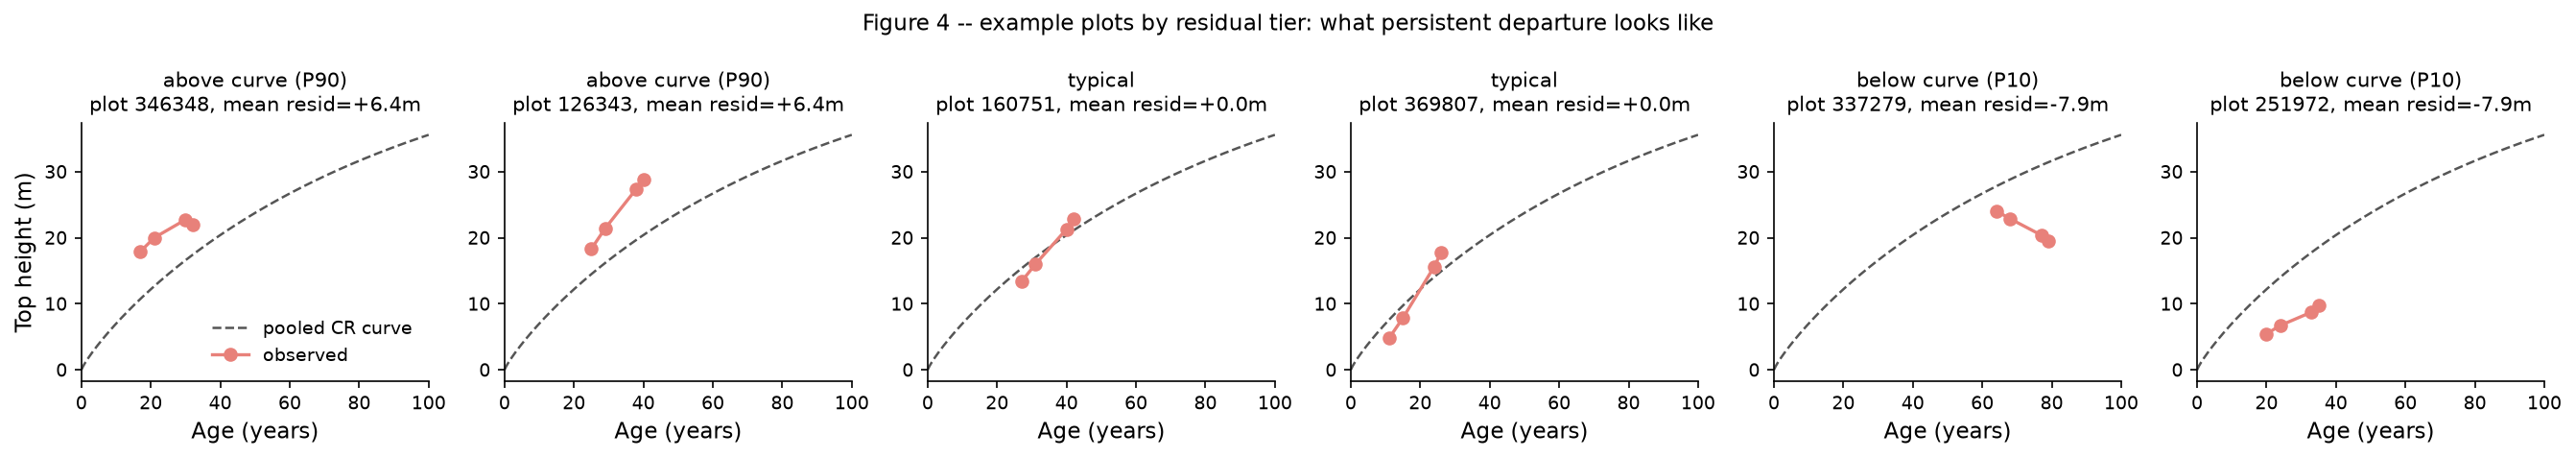

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2), sharey=False)
age_range = np.linspace(0, 100, 200)
cr_curve = chapman_richards(age_range, CR_PARAMS_4SURVEY["y_max"], CR_PARAMS_4SURVEY["k"], CR_PARAMS_4SURVEY["p"])

for ax, plot_id, label, residual in zip(axes, tier_plots, tier_labels, tier_residuals):
    plot_rows = growth_rows_fig4[growth_rows_fig4["identification"] == plot_id].sort_values("Age")
    ax.plot(age_range, cr_curve, linestyle="--", color=COLOR_NEUTRAL_EDGE, linewidth=1.2, label="pooled CR curve")
    ax.plot(plot_rows["Age"], plot_rows["elev_percentile_95th"], marker="o", color=COLOR_XGBOOST,
            linewidth=1.6, label="observed")
    ax.set_title(f"{label}\nplot {int(plot_id)}, mean resid={residual:+.1f}m", fontsize=10)
    ax.set_xlabel("Age (years)", fontsize=11)
    ax.tick_params(labelsize=9)
    ax.set_xlim(0, 100)

axes[0].set_ylabel("Top height (m)", fontsize=11)
axes[0].legend(fontsize=9, frameon=False)
fig.suptitle("Figure 4 -- example plots by residual tier: what persistent departure looks like", fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "q1_selected_fig4_example_trajectories.png", dpi=200)
plt.show()

## Appendix Figure -- VIF check

**Ported, unchanged** -- no issues found on review.

Set4 full feature context (19 columns):
                     column       vif
time_since_thinning_missing 39.710634
        time_since_thinning 22.589173
        recent_thinning_5yr  9.887345
          gwa_weibull_a_50m  3.934721
     chelsa_bio12_precip_mm  3.908805
                   tas_mean  3.440895
          local_relief_500m  3.272331
                      topex  2.368030
               dist_to_road  2.326762
          gwa_weibull_a_10m  2.236036
              slope_degrees  2.184782
         gwa_wind_speed_10m  2.177388
               soilgrids_ph  2.124465
          gwa_weibull_k_50m  1.633111
                       whcl  1.499214
                    ceh_twi  1.403136
      dist_to_scpt_boundary  1.113435
                   eastness  1.097396
                CanopyCover  1.088341


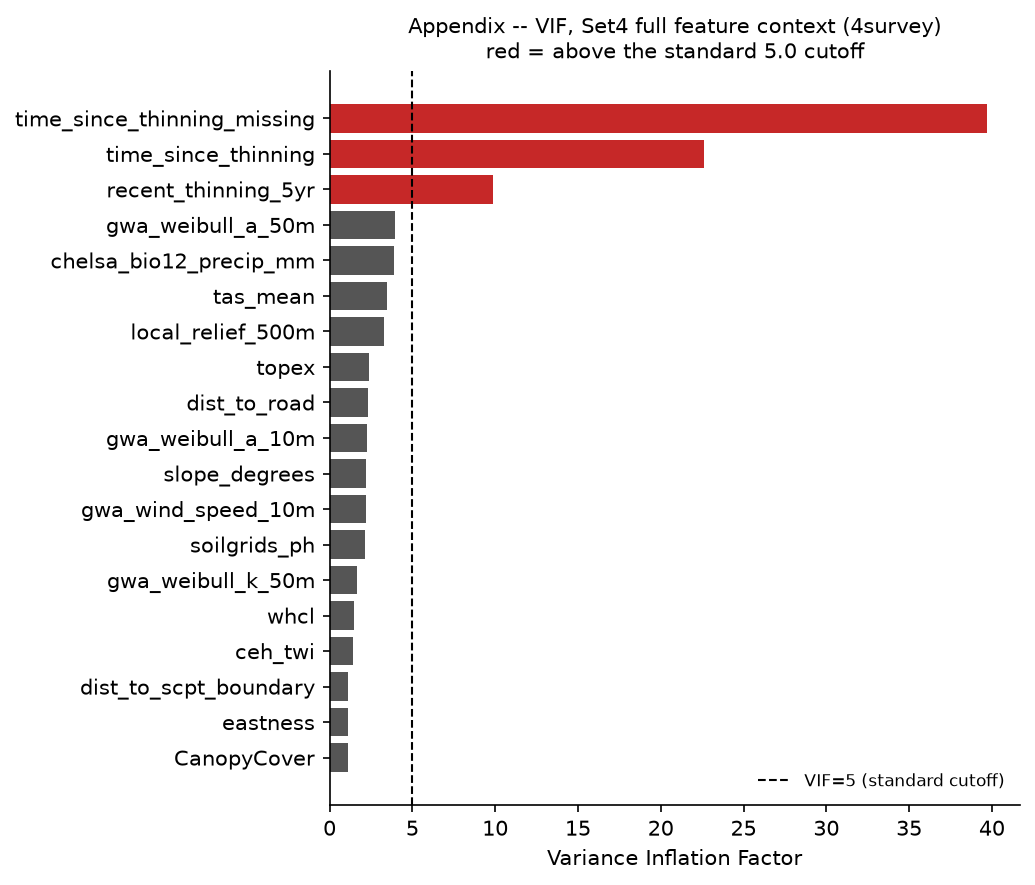

In [12]:
from models.xgb_environmental.feature_set_builder import load_feature_set
from models.xgb_environmental.multicollinearity_screen import compute_vif_table

set4_feature_columns = load_feature_set("RSQ2", "nested_set4_gated_all_vif")
vif_table = compute_vif_table(plots_with_residual, set4_feature_columns)
print(f"Set4 full feature context ({len(set4_feature_columns)} columns):")
print(vif_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
colors_vif = ["#C62828" if v > 5.0 else COLOR_NEUTRAL_EDGE for v in vif_table["vif"]]
ax.barh(vif_table["column"], vif_table["vif"], color=colors_vif)
ax.axvline(5.0, color="black", linestyle="--", linewidth=1, label="VIF=5 (standard cutoff)")
ax.invert_yaxis()
ax.set_xlabel("Variance Inflation Factor")
ax.set_title("Appendix -- VIF, Set4 full feature context (4survey)\nred = above the standard 5.0 cutoff", fontsize=10)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "q1_selected_appendix_vif.png", dpi=200)
plt.show()